<a href="https://colab.research.google.com/github/mishraaashkacs242511-maker/Aashka/blob/main/T095_Aashka_Mishra_AI_Prac_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Social_Network_Ads.csv to Social_Network_Ads (2).csv
First 5 rows of the dataset:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset shape:
(400, 5)

Missing values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Features:
   Age  EstimatedSalary
0   19            19000
1   35            20000
2   26            43000
3   27            57000
4   19            76000

Target:
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

Training samples: 320
Testing samples: 80

Feature scaling completed.

Initial SVM model trained successfully!

Initial SVM Accuracy:
90.0 %
SVM PARAMETER OPTIMIZATION
Best Parameters:
{'C': 10, 'gamma':

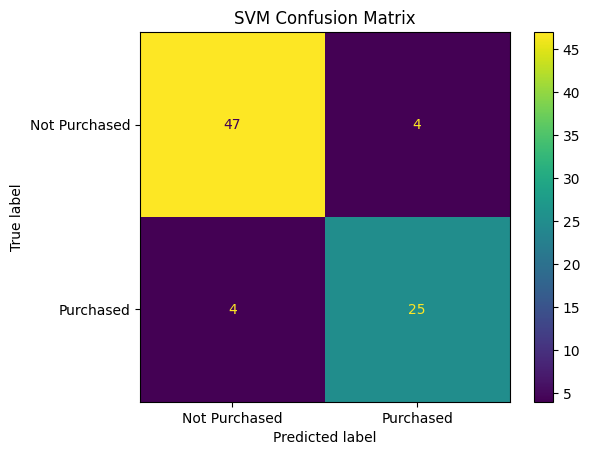


Actual vs Predicted:
    Age  EstimatedSalary  Actual  Predicted
0    48           119000       1          1
1    26            15000       0          0
2    35            20000       0          0
3    38           112000       0          1
4    20            82000       0          0
5    54            70000       1          1
6    40            75000       0          0
7    60           102000       1          1
8    59            83000       0          1
9    36            33000       0          0
10   40            57000       0          0
11   47           105000       1          1
12   47            25000       1          1
13   45            79000       0          0
14   28           123000       1          1


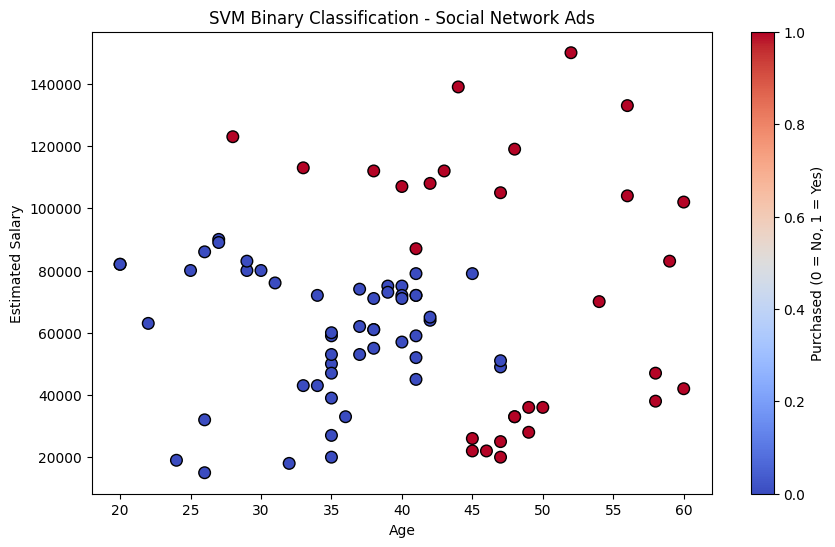

SVM PERFORMANCE COMPARISON
Initial SVM Accuracy: 90.0 %
Optimized SVM Accuracy: 90.0 %
NEW USER PREDICTION
Prediction: User is NOT likely to purchase


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

uploaded = files.upload()

df = pd.read_csv("Social_Network_Ads.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

X = df[['Age', 'EstimatedSalary']]

y = df['Purchased']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train_scaled, y_train)

print("\nInitial SVM model trained successfully!")

y_pred_initial = svm_model.predict(X_test_scaled)

initial_accuracy = accuracy_score(y_test, y_pred_initial)

print("\nInitial SVM Accuracy:")
print(round(initial_accuracy * 100, 2), "%")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("SVM PARAMETER OPTIMIZATION")


print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

best_svm = grid_search.best_estimator_

print("\nBest SVM model selected successfully!")

y_pred = best_svm.predict(X_test_scaled)

print("\nPredicted values:")
print(y_pred)

accuracy = accuracy_score(y_test, y_pred)

print("OPTIMIZED SVM RESULTS")


print("Test Accuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Purchased", "Purchased"]
    )
)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Purchased", "Purchased"]
)

disp.plot()

plt.title("SVM Confusion Matrix")

plt.show()

results = pd.DataFrame({
    'Age': X_test['Age'].values,
    'EstimatedSalary': X_test['EstimatedSalary'].values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(results.head(15))

plt.figure(figsize=(10, 6))

plt.scatter(
    X_test['Age'],
    X_test['EstimatedSalary'],
    c=y_pred,
    cmap='coolwarm',
    edgecolor='black',
    s=70
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.title("SVM Binary Classification - Social Network Ads")

plt.colorbar(
    label="Purchased (0 = No, 1 = Yes)"
)

plt.show()

print("SVM PERFORMANCE COMPARISON")


print(
    "Initial SVM Accuracy:",
    round(initial_accuracy * 100, 2),
    "%"
)

print(
    "Optimized SVM Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


new_user = [[35, 70000]]

new_user_scaled = scaler.transform(new_user)

new_prediction = best_svm.predict(new_user_scaled)

print("NEW USER PREDICTION")

if new_prediction[0] == 1:
    print("Prediction: User is likely to PURCHASE")
else:
    print("Prediction: User is NOT likely to purchase")